# Week 3: Black-Scholes-Merton Pricing

This notebook covers the Black-Scholes-Merton (BSM) option pricing model — the continuous-time culmination of Weeks 1 and 2.

- **Week 1** gave us GBM — how stock prices move randomly over time
- **Week 2** gave us no-arbitrage and risk-neutral pricing in discrete time
- **Week 3** combines both into a single closed-form pricing formula

The key result: given a stock price, strike, rate, volatility, and time — BSM outputs the **one fair price** for a European option.

In [1]:
from scipy.stats import norm
from math import log, sqrt, exp
import numpy as np
import matplotlib.pyplot as plt

## BSM Assumptions

BSM lives in an idealized world with the following assumptions:

- **Constant volatility (σ)** — volatility doesn't change over time
- **Continuous trading** — you can rebalance your hedge at every instant
- **No dividends** — the stock pays no dividends during the option's life
- **No transaction costs** — trading is frictionless
- **No arbitrage** — no free money exists
- **Constant risk-free rate (r)** — interest rates don't change

These simplifications make the math tractable but break in the real world. Weeks 8–10 address what happens when they fail.

## The BSM Formula

For a **European call** option:
$$C = S_0 N(d_1) - K e^{-rT} N(d_2)$$

For a **European put** option:
$$P = K e^{-rT} N(-d_2) - S_0 N(-d_1)$$

Where:
$$d_1 = \frac{\ln(S_0/K) + (r + \sigma^2/2)T}{\sigma\sqrt{T}}$$
$$d_2 = d_1 - \sigma\sqrt{T}$$

**What each piece means:**
- $N(d_1)$ — the option's **delta**: how much the option price moves per \$1 move in the stock. This is the same delta from Week 2's riskless portfolio.
- $N(d_2)$ — probability the option **expires in the money** (i.e. exercise will be profitable)
- $Ke^{-rT}$ — present value of the strike price (same discounting logic from Week 2)

Notably, **drift (μ) appears nowhere in the formula** — confirming the risk-neutral world insight from Weeks 1 and 2. Only the risk-free rate matters for pricing.

In [2]:
def d_1(sigma, s_0, k, r, T):
    return (log(s_0/k) + (r + (sigma**2)/2) * T) / (sigma * sqrt(T))

def d_2(sigma, s_0, k, r, T):
    return d_1(sigma, s_0, k, r, T) - sigma * sqrt(T)

def bsm_call(sigma, s_0, k, r, T):
    d1 = d_1(sigma, s_0, k, r, T)
    d2 = d_2(sigma, s_0, k, r, T)
    return s_0 * norm.cdf(d1) - k * exp(-r * T) * norm.cdf(d2)

def bsm_put(sigma, s_0, k, r, T):
    d1 = d_1(sigma, s_0, k, r, T)
    d2 = d_2(sigma, s_0, k, r, T)
    return k * exp(-r * T) * norm.cdf(-d2) - s_0 * norm.cdf(-d1)

# Parameters
s_0 = 100
k = 110
r = 0.04
T = 0.25
sigma = 0.20

call = bsm_call(sigma, s_0, k, r, T)
put = bsm_put(sigma, s_0, k, r, T)

print(f"Call Price: {call:.3f}")
print(f"Put Price:  {put:.3f}")
print(f"N(d1) / Delta: {norm.cdf(d_1(sigma, s_0, k, r, T)):.4f}")
print(f"N(d2) / P(ITM): {norm.cdf(d_2(sigma, s_0, k, r, T)):.4f}")

Call Price: 1.140
Put Price:  10.046
N(d1) / Delta: 0.2110
N(d2) / P(ITM): 0.1832


## Observations — Call vs Put

With S₀=100 and K=110, the stock needs to climb 10% just to reach the strike:

- **Call = \$1.14** — cheap, because the option is out of the money (OTM). Low probability of reaching \$110 in 3 months.
- **Put = \$10.05** — expensive, because the option is already in the money (ITM). The right to sell at \$110 when the stock is at \$100 is immediately valuable.

**Option moneyness jargon:**
- **ITM (In the Money)** — exercising now would be profitable
- **OTM (Out of the Money)** — exercising now would lose money
- **ATM (At the Money)** — stock price ≈ strike price

## Put-Call Parity Verification

Put-call parity states that for options with the same strike and expiry:
$$C - P = S_0 - Ke^{-rT}$$

If this holds, the pricer is internally consistent. Any violation would imply arbitrage.

In [3]:
net_premium = call - put
parity = s_0 - k * exp(-r * T)

print(f"C - P:           {net_premium:.4f}")
print(f"S - Ke^(-rT):    {parity:.4f}")
print(f"Parity holds:    {np.isclose(net_premium, parity)}")

C - P:           -8.9055
S - Ke^(-rT):    -8.9055
Parity holds:    True


## Implied Volatility

BSM takes σ as an input and outputs a price. **Implied volatility flips this** — given a market option price, we work backwards to find what σ the market is implying.

This can't be solved analytically (no way to isolate σ algebraically), so we use **Newton's method** — an iterative numerical approach:

1. Start with a sigma guess
2. Run BSM → compare output to market price
3. Adjust sigma using: $\sigma_{new} = \sigma_{old} - \frac{BSM(\sigma) - \text{market price}}{Vega}$
4. Repeat until convergence

**Vega** here is the sensitivity of the option price to changes in σ — it tells us how big our next adjustment should be.

In [4]:
def implied_vol_call(call_market_price, s_0, k, r, T):
    """
    Recover implied volatility from a call market price using Newton's method.
    Uses call prices only — put IV solver showed instability due to low Vega
    in deep OTM/ITM scenarios, causing Newton's method to diverge.
    In production: enforce put-call parity or use bisection method instead.
    """
    sigma = 0.20  # initial guess
    for i in range(100):
        d1 = d_1(sigma, s_0, k, r, T)
        price = bsm_call(sigma, s_0, k, r, T)
        vega = s_0 * sqrt(T) * norm.pdf(d1)
        
        if vega < 1e-8:  # vega too small → formula undefined
            break
        
        old_sigma = sigma
        sigma = sigma - 0.5 * (price - call_market_price) / vega  # 0.5 damping for stability
        sigma = max(1e-6, min(sigma, 5))  # keep sigma in reasonable bounds
        
        if abs(old_sigma - sigma) < 1e-6:  # converged
            return sigma
    return None

# Test: generate a call price with known sigma, then recover it
known_sigma = 0.25
test_call_price = bsm_call(known_sigma, 100, 100, 0.05, 1.0)
recovered_sigma = implied_vol_call(test_call_price, 100, 100, 0.05, 1.0)

print(f"Known sigma:     {known_sigma:.4f}")
print(f"Test call price: {test_call_price:.4f}")
print(f"Recovered sigma: {recovered_sigma:.4f}")
print(f"Match: {np.isclose(known_sigma, recovered_sigma, atol=1e-4)}")

Known sigma:     0.2500
Test call price: 12.3360
Recovered sigma: 0.2500
Match: True


## Implied Vol Across Strike Prices

If BSM were perfect, implied volatility would be the same across all strikes. 
Let's check — this is a preview of the **volatility smile** from Week 8.

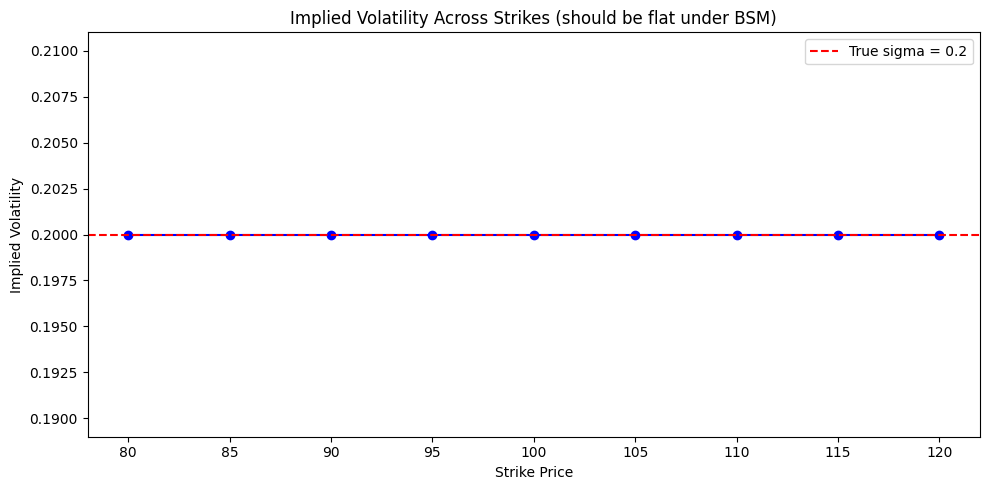

Note: Flat line confirms BSM is internally consistent.
In real markets this line is NOT flat — that's the volatility smile (Week 8).


In [5]:
strikes = np.arange(80, 125, 5)
true_sigma = 0.20
s_0, r, T = 100, 0.05, 1.0

# Generate market prices with known sigma
market_prices = [bsm_call(true_sigma, s_0, k, r, T) for k in strikes]

# Recover implied vols
implied_vols = [implied_vol_call(p, s_0, k, r, T) for p, k in zip(market_prices, strikes)]

plt.figure(figsize=(10, 5))
plt.plot(strikes, implied_vols, marker='o', color='blue')
plt.axhline(y=true_sigma, color='red', linestyle='--', label=f'True sigma = {true_sigma}')
plt.title('Implied Volatility Across Strikes (should be flat under BSM)')
plt.xlabel('Strike Price')
plt.ylabel('Implied Volatility')
plt.legend()
plt.tight_layout()
plt.show()

print("Note: Flat line confirms BSM is internally consistent.")
print("In real markets this line is NOT flat — that's the volatility smile (Week 8).")

## Weekly Takeaways

Week 3 is where Weeks 1 and 2 collide. GBM (Week 1) provides the stochastic process for stock prices. No-arbitrage and risk-neutral pricing (Week 2) provide the valuation logic. BSM combines both into a closed-form formula.

The most important insight: **drift disappears**. The formula contains σ, r, T, S, K — but never μ. This is the continuous-time confirmation of everything learned in Week 2.

The implied vol solver shows that BSM is invertible — markets quote option prices, and we can back out the market's implied view on future volatility. This number (aggregated across many options) is essentially what the VIX measures every day.

What BSM assumes away — constant volatility, continuous trading, no dividends — is what the rest of this syllabus systematically relaxes. Week 4 starts by measuring how sensitive the BSM price is to each of its inputs. Those sensitivities are the Greeks.